In [21]:
# Add the parent directory to the path so that we can import the src module
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [22]:
from src.camera import CameraCalibration, Camera
from src.pose.position_estimation import PositionEstimation
from src.pose.velocity_regression import velocity_regression
from src.ukf import BallUKF
from src.ukf.measurement import PixelPositionMeasurementMode
from src.fileutils import DATA_DIR
import src.visualization.plot3D as plot3D
from src.parse_config import Config

from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import numpy as np
from itertools import islice
import pickle

In [23]:
CONFIG_PATH = DATA_DIR / 'videos' / '3' / 'config.yaml'
config = Config.from_yaml(CONFIG_PATH)
config.load_images()

background = config.background_image
video = config.video
dt = 1 / config.fps

In [24]:
# Run calibration
calibration_video = config.calibration_video
calibration = CameraCalibration.from_calibration_video(tqdm(calibration_video))
calibration.intrinsic_matrix

866it [00:28, 30.43it/s]


array([[1.77359284e+03, 0.00000000e+00, 9.11756034e+02],
       [0.00000000e+00, 2.18801937e+03, 5.44315604e+02],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

In [25]:
# Initialize camera based on calibration
camera = Camera(config.camera_pose, calibration)

# Create ball and table constants
BALL = config.ball_constants
TABLE = config.table_constants

In [26]:
# Load boxes and raw measurements
with open(DATA_DIR / 'output' / 'test_yolo_measured_boxes.pkl', 'rb') as f:
    boxes = pickle.load(f)
with open(DATA_DIR / 'output' / 'test_yolo_measured_positions.pkl', 'rb') as f:
    measured_positions = pickle.load(f)

In [27]:
%matplotlib widget
PLOT_BACKEND = 'plotly' # 'matplotlib' or 'plotly'

if PLOT_BACKEND == 'matplotlib':

    # Plot raw measured_positions
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    plot3D.plot_table(ax, TABLE, table_color = 'green', net_color = 'grey', table_alpha=0.4, net_alpha=1)
    plot3D.plot_camera(ax, camera)
    measured_positions_without_none = [position for position in measured_positions if position is not None]
    plot3D.plot_trajectory(ax, np.array(measured_positions_without_none), color='red')

    plt.show()

elif PLOT_BACKEND == 'plotly':
    
    import src.visualization.plotly3D as plotly3D
    import plotly.graph_objects as go

    fig = go.Figure()

    plotly3D.plot_camera(fig, camera)
    plotly3D.plot_table(fig, TABLE, table_alpha=0.8, net_alpha=1, net_color = 'black', table_color='green')
    measured_positions_without_none = [position for position in measured_positions if position is not None]
    plotly3D.plot_trajectory(fig, np.array(measured_positions_without_none), color='red')
    fig.show()



In [28]:
# Initialize the position estimator
position_estimator = PositionEstimation(camera, BALL, TABLE)

In [29]:
CONFIG_PATH = DATA_DIR / 'videos' / '3' / 'config.yaml'
config = Config.from_yaml(CONFIG_PATH)
config.load_images()

background = config.background_image
video = config.video
dt = 1 / config.fps

n_initialization_frames = config.setup_frames


print("Video FPS (can be specified in config file to override value from OpenCV):", config.fps)
print(video)

Video FPS (can be specified in config file to override value from OpenCV): 210.46
VideoStream:
	Source: C:\Users\agpri\OneDrive\Documents\GitHub\PingPongTracking\data\videos\3\3.MOV
	FPS: 30.0
	Frames: 900
	Resolution: 1920x1080



In [30]:
annotated_frames = []      # Annotated frames
states = []                # UKF states

Frame 0
Box Center: (1794.0, 248.0), Min Length: 24
Ball position table ref  [ 1.47040661 -0.04401193  1.65031885] at time 0.0
Ball position camera ref [ 1.47040661 -0.40031885  2.95598807] at time 0.0
Loaded measured position [1.53433733 0.08450929 1.66772401]


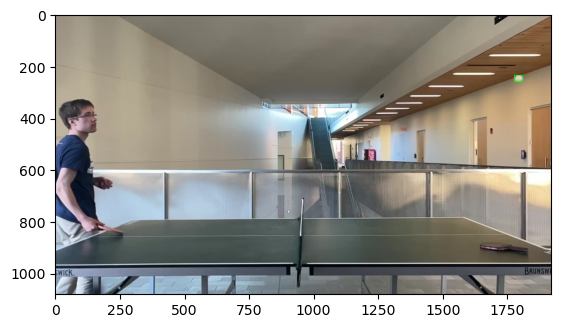

Frame 1
Box Center: (1784.0, 247.0), Min Length: 25
Ball position table ref  [ 1.39559035 -0.16225146  1.63560304] at time 0.004751496721467262
Ball position camera ref [ 1.39559035 -0.38560304  2.83774854] at time 0.004751496721467262
Loaded measured position [1.51694603 0.08450929 1.66913374]


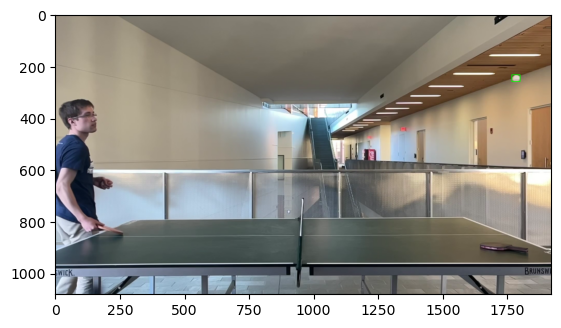

In [31]:
%matplotlib inline

diameter_multiplier = 0.97

for i, frame in enumerate(config.get_setup_video_iter()):

    annotated_frame = frame.copy()
    box = boxes[i]

    if box is not None:
        print(f"Frame {i}")
        
        center_x = (box[0] + box[2]) // 2
        center_y = (box[1] + box[3]) // 2
        diameter = min(box[2] - box[0], box[3] - box[1]) * diameter_multiplier
        diameter = int(diameter)
        print(f"Box Center: ({center_x}, {center_y}), Min Length: {diameter}")

        # Get the ball position
        ball_position = position_estimator.ball_position_table_reference_frame(center_x, center_y, diameter)
        ball_position_cam = position_estimator.ball_position_camera_reference_frame(center_x, center_y, diameter)


        print(f"Ball position table ref  {ball_position} at time {i * dt}")
        print(f"Ball position camera ref {ball_position_cam} at time {i * dt}")
        print(f"Loaded measured position {measured_positions[i]}")

        # draw the bounding box
        cv2.rectangle(annotated_frame, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), (0, 255, 0), 2)

    else:
        print("No ball detected")

    
    plt.figure()
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.show()

    annotated_frames.append(annotated_frame)  

In [32]:
# Linear regression over initial positions to get initial velocity
initial_positions = np.array([measured_position for measured_position in measured_positions[:n_initialization_frames] if measured_position is not None])
initial_times = np.arange(0, len(initial_positions) * dt, dt)
initial_velocity, intercept = velocity_regression(initial_times, initial_positions)
print(f"Initial velocity: {initial_velocity}")

# Keep track of the states
states = [
    np.array([*initial_positions[i], 0, 0, 0, *initial_velocity, 0, 0, 0]) for i in range(len(initial_positions))
]

# Plot x, y and and z positions on 3 seperate scatter plots
# Also plot the regression lines
PLOT_VELOCITIES = False
if PLOT_VELOCITIES:
    for i in range(3):
        plt.figure()
        pos_axes = ['X', 'Y', 'Z']
        plt.scatter(initial_times, initial_positions[:, i])
        plt.plot(initial_times, initial_velocity[i] * initial_times + intercept[i], color='red')
        plt.xlabel("Time (s)")
        plt.ylabel(f"Position {pos_axes[i]} (m)")
        plt.title(f"Position {pos_axes[i]} vs time")
        plt.show()


print("Kalman Initial state: ", states[-1])

Initial velocity: [-3.66017391  0.          0.29669108]
Kalman Initial state:  [ 1.51694603  0.08450929  1.66913374  0.          0.          0.
 -3.66017391  0.          0.29669108  0.          0.          0.        ]


In [33]:
# Initialize Kalman Filter

# Measurement noise is in units of pixels since we are using PixelPositionMeasurementMode
# There is more noise in the depth measurement (diameter in pixels)
measurement_noise = np.array(
   [[1, 0, 0],
    [0, 1, 0],
    [0, 0, 4]]
)

measurement_mode = PixelPositionMeasurementMode(measurement_noise, position_estimator)

initial_state = states[-1]
initial_covariance = np.eye(12) * 1 # Initial covariance should be large

process_noise = np.eye(12) * 0.1 * dt

ukf = BallUKF(BALL, initial_state, initial_covariance, process_noise, measurement_mode)

In [34]:
for i, frame in islice(enumerate(config.get_analysis_video_iter(video)), n_initialization_frames, None):
    
    annotated_frame = frame.copy()
    ukf.predict(dt)
    predicted_state = ukf.state

    box = boxes[i]

    
    if box is not None:
        
        cv2.rectangle(annotated_frame, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), (0, 255, 0), 2)

        center_x = (box[0] + box[2]) // 2
        center_y = (box[1] + box[3]) // 2
        diameter = int(min(box[2] - box[0], box[3] - box[1]) * 0.97)
        
        measured_position = position_estimator.ball_position_table_reference_frame(center_x, center_y, diameter)
        
        # Since we are using PixelPositionMeasurementMode, the measurement is in pixels
        ukf.update(np.array([center_x, center_y, diameter]))


    # Project the kalman state onto the ball and draw in red
    updated_projection = position_estimator.project_ball_position_table_reference_frame_to_camera_plane(ukf.state[:3])
    annotated_frame = cv2.circle(annotated_frame, (int(updated_projection[0]), int(updated_projection[1])), updated_projection[2]//2, (0, 0, 255), 4)


    states.append(ukf.state)
    annotated_frames.append(annotated_frame)

    # create a new figure and plot the camera, table and trajectory so far'
    if i % 1000 == 0:


        plt.figure()
        plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        plt.show()
        
        print(f"Frame {i}")
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        plot3D.plot_table(ax, TABLE)
        plot3D.plot_camera(ax, camera)
        measured_positions_without_none = [position for position in measured_positions if position is not None]
        plot3D.plot_trajectory(ax, np.array(measured_positions_without_none), color='red')  
        plt.show()

        # Plot the UKF states
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        plot3D.plot_table(ax, TABLE)
        plot3D.plot_camera(ax, camera)
        ukf_positions = np.array([state[:3] for state in states])
        plot3D.plot_trajectory(ax, ukf_positions, color='red')
        plt.show()

    if i in [123]:
        # reset state covariance after bounce
        # temporary before we add bounce detection based on height
        ukf.ukf.P = initial_covariance


In [36]:
# Save the annotated images as a video
output_path = str(DATA_DIR / "output" / "annotated_ukf.mp4")
writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), config.fps, (video.width, video.height))
for image in annotated_frames:
    writer.write(image)
writer.release()

In [37]:
%matplotlib widget

if PLOT_BACKEND == 'matplotlib':

    # Plot raw measured_positions
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    plot3D.plot_table(ax, TABLE, table_color = 'green', net_color = 'grey', table_alpha=0.4, net_alpha=1)
    plot3D.plot_camera(ax, camera)
    measured_positions_without_none = [position for position in measured_positions if position is not None]
    plot3D.plot_trajectory(ax, np.array(states)[:, :3], color='red')

    plt.show()

elif PLOT_BACKEND == 'plotly':
    
    import src.visualization.plotly3D as plotly3D
    import plotly.graph_objects as go

    fig = go.Figure()

    plotly3D.plot_camera(fig, camera)
    plotly3D.plot_table(fig, TABLE, table_alpha=0.8, net_alpha=1, net_color = 'black', table_color='green')
    measured_positions_without_none = [position for position in measured_positions if position is not None]
    plotly3D.plot_trajectory(fig, np.array(states)[:, :3], color='red')
    fig.show()

In [38]:
# Save states to a pickle file
import pickle
output_path = str(DATA_DIR / "output" / "ukf_states.pkl")
with open(output_path, 'wb') as f:
    pickle.dump(states, f)